In [1]:
# mega notebook to combine Jelis and Samuel work

In [2]:
from landlab import RasterModelGrid,  imshow_grid
from landlab.plot.graph import plot_graph
import matplotlib.pyplot as plt

<Axes: xlabel='x', ylabel='y'>

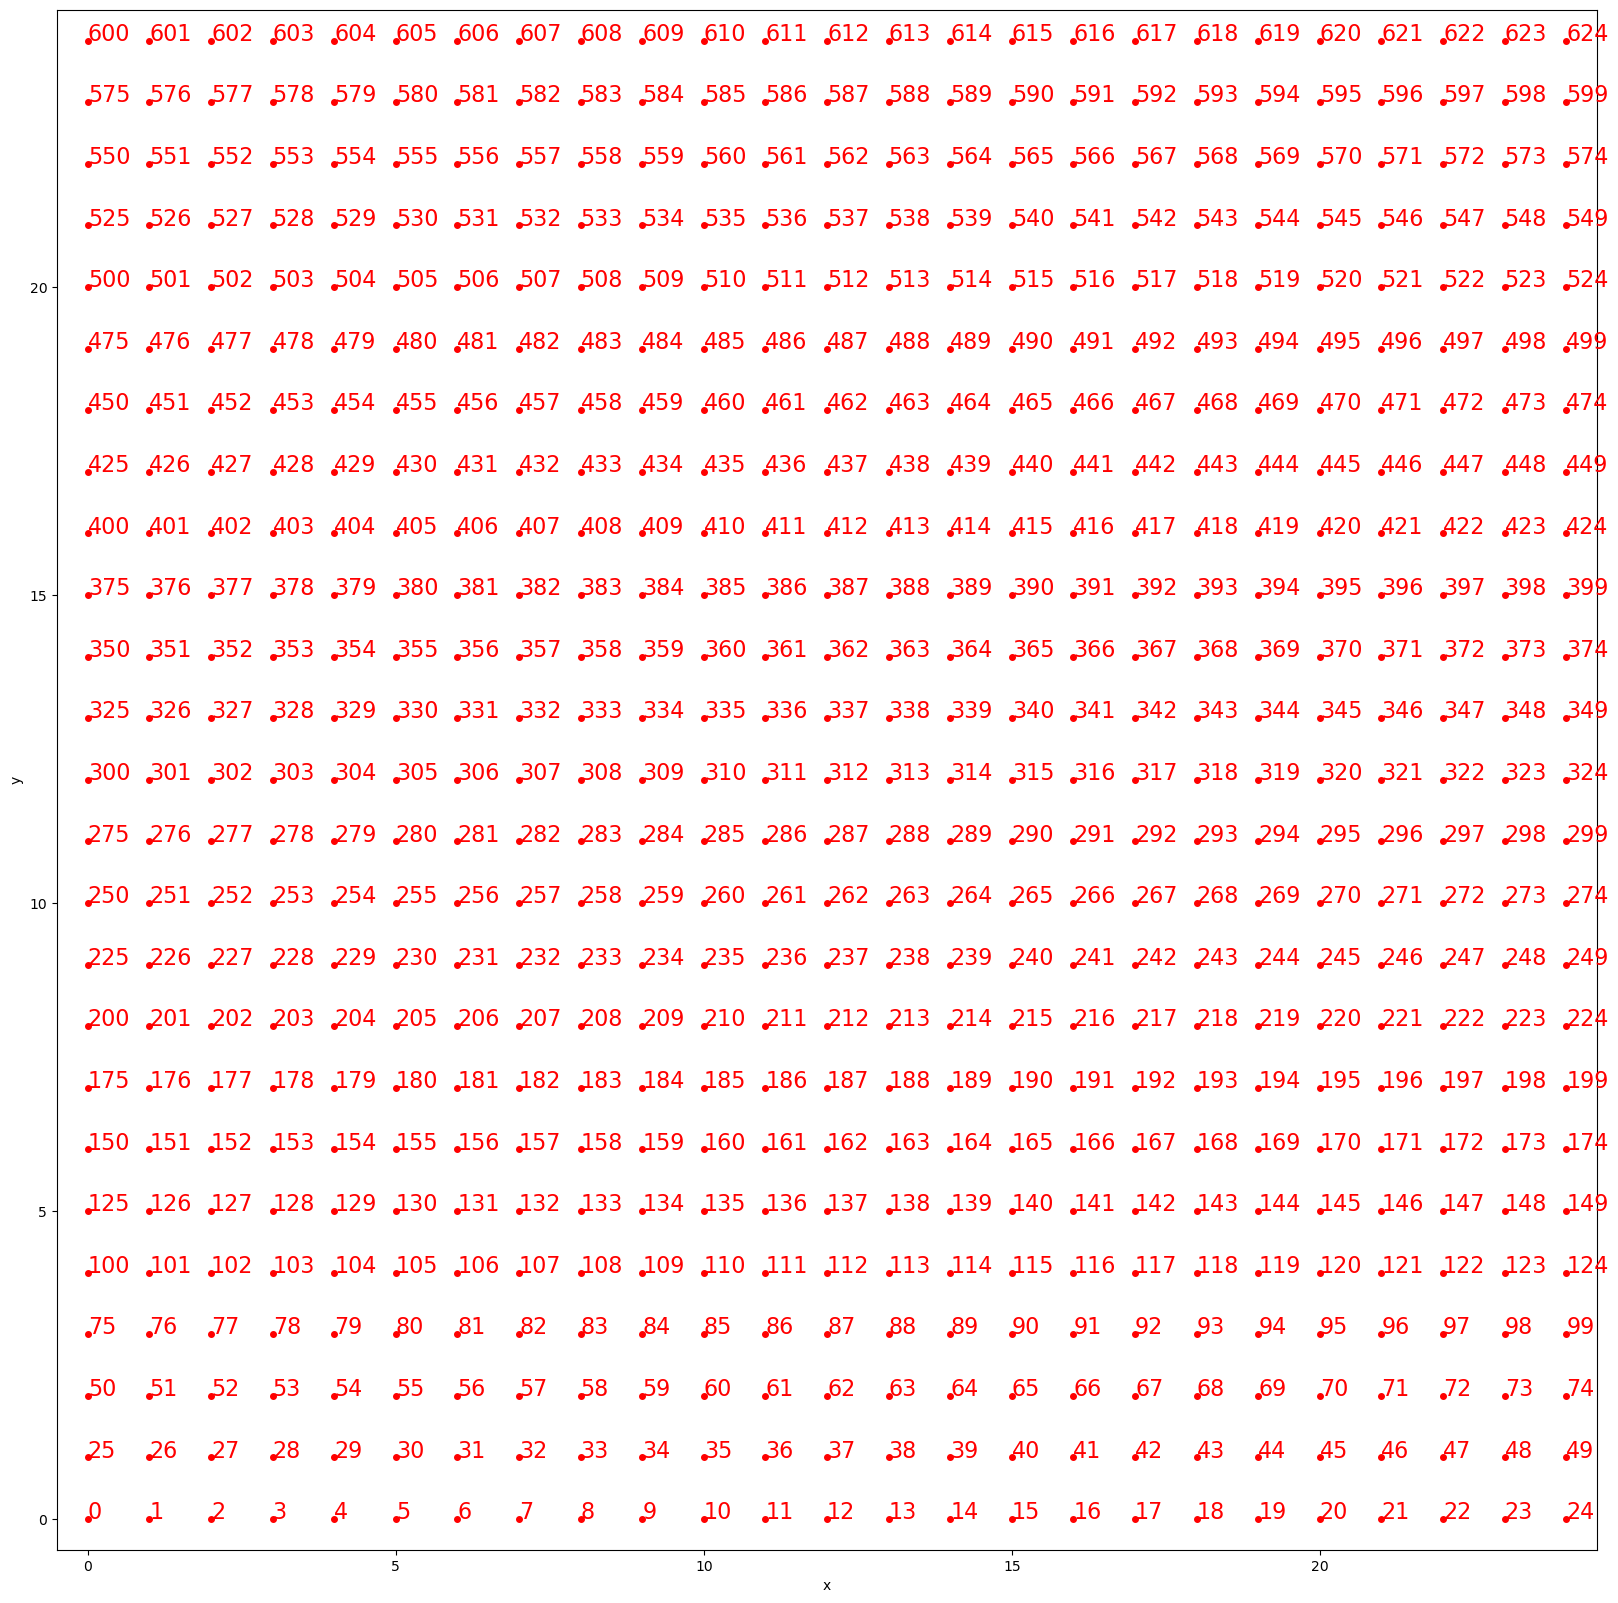

In [3]:
nrows = 25 #grid number of rows
ncols = 25 #grid number of columns
dx = 1 #grid cell spacing
grid = RasterModelGrid((nrows, ncols), dx)
plt.figure(figsize=(20, 20))
plot_graph(grid, at="node")

In [4]:
temp = grid.add_zeros("temp", at="node")
grid.at_node["temp"][grid.x_of_node<=25-grid.y_of_node] = -1
grid.set_closed_boundaries_at_grid_edges(True, True, True, True)
grid.at_node["temp"] #sanity check

array([-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1.,  0., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1.,  0.,  0., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1.,  0.,  0.,  0., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1.,  0.,  0.,  0.,  0., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1.,  0.,  0.,  0.,  0.,  0., -1., -1., -1., -1., -1., -1

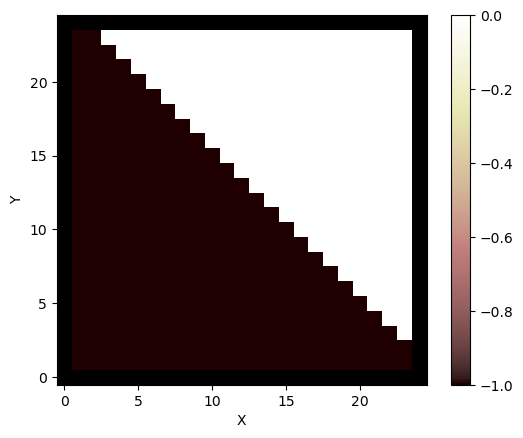

In [5]:
# visualize temperature distribution
grid.imshow(temp)

In [6]:
# manually "remove" clay cells
temp[(73,217,337,481,553),] = 15

# diags = [97, 241, 361, 

# set all air to 15 degrees
temp[grid.at_node["temp"] == 0] = 15 #set air nodes to 15 deg Celsius

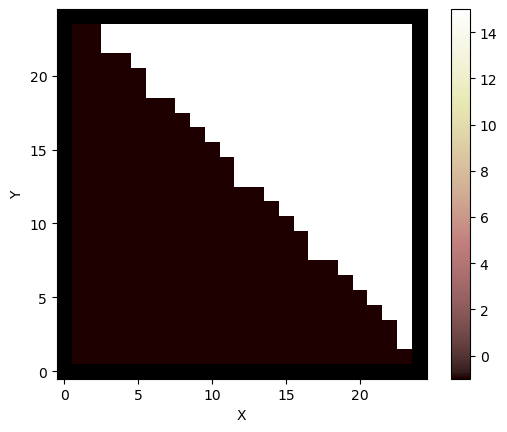

In [7]:
grid.imshow(temp)

In [8]:
import numpy as np

is_clay = grid.add_field("is_clay", np.zeros(grid.shape), at="node")
is_clay0 = grid.at_node["is_clay"].copy()
grid.at_node["is_clay"][grid.at_node["temp"] < 0] = 1
# is_clay = grid.at_node["temp"] == -1 #define frozen clay nodes
# is_air = temp[grid.at_node["temp"] == 0] = 15 #set air nodes to 15 deg Celsius

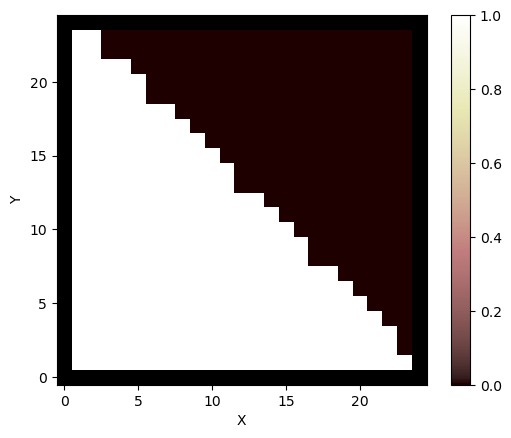

In [9]:
grid.imshow(is_clay)

In [10]:
def is_interior(grid, node):
    # determine whether node is on bottom or right boundary
    x, y = grid.x_of_node[node], grid.y_of_node[node]
    return y > 0 and (x < grid.shape[1] - 1) and grid.at_node['is_clay'][node] == 1

In [11]:
# should be false -- lower boundary
print(is_interior(grid, 1))

False


In [12]:
# should be false -- right boundary
print(is_interior(grid, 624))

False


In [13]:
# should be true
print(is_interior(grid, 55))

True


In [14]:
def is_thawed(grid, node):
    return grid.at_node["temp"][node] >= 0     

In [15]:
# should return false
print(is_thawed(grid, 5))

False


In [16]:
# should return true
print(is_thawed(grid, 518))

True


In [17]:
def get_downright_node(grid, node, dx):
    if is_interior(grid, node):
        x, y = grid.x_of_node[node], grid.y_of_node[node]
        #print(f"x={x}, y={y}")
        diag_node = grid.find_nearest_node([x+dx, y-dx]) # check this
        #print(f"diag node={diag_node}")
        return diag_node
    else:
        return ValueError("must be an interior node")

In [18]:
# 5 should return 286
print(get_downright_node(grid, 310, dx))

286


In [19]:
# 0 should raise error
print(get_downright_node(grid, 0, dx))

must be an interior node


In [20]:
# assesses whether down-right is soil (or air)
def downright_is_open(grid, node, dx):
    # check for not bottom or right boundary
    # initially was not checking to also be clay
    if is_interior(grid, node) and grid.at_node["is_clay"][node] == 1:     
        diag_node = get_downright_node(grid, node, dx)
        return grid.at_node['is_clay'][diag_node] == False
    else:
        return False # safety
        

In [21]:
# should return true -- pulled node 73
print(downright_is_open(grid, 97, dx))

True


In [22]:
# should return false
print(downright_is_open(grid, 5, dx))

False


In [23]:
# false -- right lower corner
print(downright_is_open(grid, 24, dx))

False


In [24]:
def slide_node(grid, node, diag_node):
    # switch materials from clay to air and air to clay
    grid.at_node["is_clay"][node] = 0 # set current node to air
    grid.at_node["is_clay"][diag_node] = 1 # set down diag to clay
    
    #store this node's temp
    temp_temp = grid.at_node["temp"][node]

    # retrieve diagonal node's temp
    diag_temp = grid.at_node["temp"][diag_node]
    
    # switch the temperatures
    grid.at_node["temp"][node] = diag_temp
    grid.at_node["temp"][diag_node] = temp_temp

In [25]:
def slide_if_thawed(grid, node, dx):
    if downright_is_open(grid, node, dx) and is_thawed(grid,node):
        diag_node = get_downright_node(grid, node, dx)
        slide_node(grid, node, diag_node)

slide_if_thawed(grid, 97, dx)

grid.imshow(is_clay)

# adjust temp manually for test
grid.at_node["temp"][97] = 0

slide_if_thawed(grid, 97, dx)

# visualize temperature distribution
grid.imshow(is_clay)

In [26]:
# prepare diffusion parameters
kappa = 1.5 * 1e-6
courant = 0.1  # Courant number for finite-volume solution
dt = courant * dx * dx / kappa  # time-step duration, s
dt = min(dt, 3600.0 * 24)
n_time_steps = int(1e3)

In [27]:
# diffusion cell

for t in range(n_time_steps):
    temp[grid.at_node['is_clay'] == 0] = 5
    Tgrad = grid.calc_grad_at_link(temp)
    #q[grid.active_links] = Tgrad[grid.active_links]
    #dTdt = kappa * grid.calc_flux_div_at_node(q)
    dTdt = kappa * grid.calc_flux_div_at_node(Tgrad)
    temp += dTdt * dt

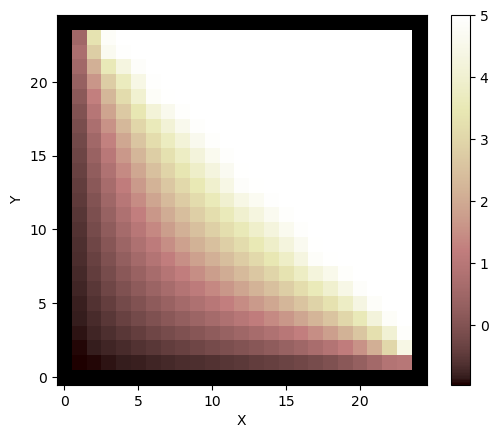

In [28]:
grid.imshow(temp)

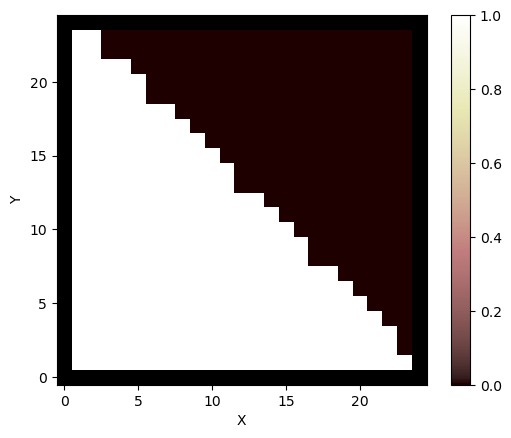

In [29]:
grid.imshow(is_clay)

In [30]:
for n in range(grid.number_of_nodes):
    if is_interior(grid, n):
        slide_if_thawed(grid, n, dx)

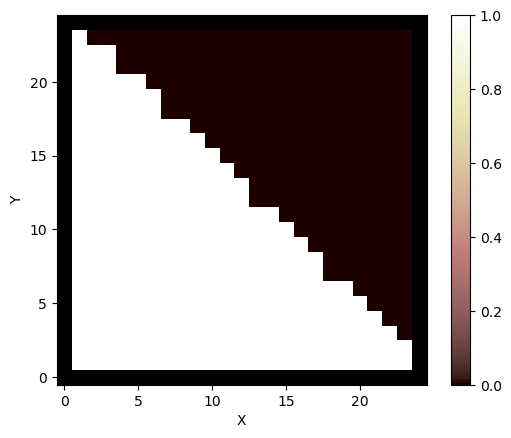

In [31]:
grid.imshow(is_clay)